In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from scipy.stats import binomtest

import xgboost as xgb

print("✅ Import réussi")
print(f"XGBoost version : {xgb.__version__}")


✅ Import réussi
XGBoost version : 3.1.0


In [15]:
import os

# Chemin de votre fichier
DATA_PATH = r"C:\Users\alexis steevenson\Documents\base_de_donnees_macro.xlsx"

# Dossier de sortie
OUTPUT_PATH = r"C:\Users\alexis steevenson\Documents\forex_research_outputs"
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH + "\\figures", exist_ok=True)
os.makedirs(OUTPUT_PATH + "\\results", exist_ok=True)

# Paires à analyser
PAIRS = ['eurusd', 'eurjpy', 'usdchf', 'usdcad', 'audusd']

# Variables explicatives
FEATURES = [
    'croiss_b', 'croiss_c', 'diff_croiss',
    'taux_int_b', 'taux_int_c', 'diff_taux_int',
    'infl_b', 'infl_c', 'diff_infl',
    'chomage_b', 'chomage_c', 'diff_chomage',
    'b_com_b', 'b_com_c',
    'mas_mon_b', 'mas_mon_c', 'diff_mas_mon',
    'vix', 'prix_du_pe'
]

# Variable cible
TARGET = 'direc_binaire'

print("✅ Paramètres définis")
print(f"Paires : {PAIRS}")
print(f"Nombre de features : {len(FEATURES)}")
print(f"Dossier sortie : {OUTPUT_PATH}")

✅ Paramètres définis
Paires : ['eurusd', 'eurjpy', 'usdchf', 'usdcad', 'audusd']
Nombre de features : 19
Dossier sortie : C:\Users\alexis steevenson\Documents\forex_research_outputs


In [16]:
# Chargement du fichier Excel
print("Chargement du fichier...")
df_raw = pd.read_excel(DATA_PATH, sheet_name=None)

print(f"\n✅ Fichier chargé")
print(f"Feuilles trouvées : {list(df_raw.keys())}")

# Vérifier chaque paire
for pair in PAIRS:
    if pair in df_raw:
        df = df_raw[pair]
        print(f"\n{pair.upper()} :")
        print(f"  Lignes : {len(df)}")
        print(f"  Colonnes : {len(df.columns)}")
        print(f"  Premières colonnes : {list(df.columns)[:8]}")
        if TARGET in df.columns:
            print(f"  ✅ {TARGET} présente")
            print(f"  Distribution : {df[TARGET].value_counts().to_dict()}")
        else:
            print(f"  ❌ {TARGET} ABSENTE")
    else:
        print(f"\n{pair.upper()} : NON TROUVÉE")

Chargement du fichier...

✅ Fichier chargé
Feuilles trouvées : ['eurusd', 'eurjpy', 'usdchf', 'audusd', 'usdcad']

EURUSD :
  Lignes : 255
  Colonnes : 25
  Premières colonnes : ['date', 'croiss_b', 'croiss_c', 'diff_croiss', 'taux_int_b', 'taux_int_c', 'diff_taux_int', 'infl_b']
  ✅ direc_binaire présente
  Distribution : {0: 130, 1: 125}

EURJPY :
  Lignes : 266
  Colonnes : 25
  Premières colonnes : ['date', 'croiss_b', 'croiss_c', 'diff_croiss', 'taux_int_b', 'taux_int_c', 'diff_taux_int', 'infl_b']
  ✅ direc_binaire présente
  Distribution : {1: 147, 0: 119}

USDCHF :
  Lignes : 259
  Colonnes : 25
  Premières colonnes : ['date', 'croiss_b', 'croiss_c', 'diff_croiss', 'taux_int_b', 'taux_int_c', 'diff_taux_int', 'infl_b']
  ✅ direc_binaire présente
  Distribution : {0: 139, 1: 120}

USDCAD :
  Lignes : 259
  Colonnes : 25
  Premières colonnes : ['date', 'croiss_b', 'croiss_c', 'diff_croiss', 'taux_int_b', 'taux_int_c', 'diff_taux_int', 'infl_b']
  ✅ direc_binaire présente
  Distri

In [17]:
def preprocess_pair(df, pair_name, features, target, test_size=0.3):
    """
    Prétraitement simple : tri par date, séparation temporelle, standardisation.
    """
    # Copie et tri par date
    data = df.copy()
    data['date'] = pd.to_datetime(data['date'])
    data = data.sort_values('date').reset_index(drop=True)
    
    # Vérifier les features disponibles
    available_features = [f for f in features if f in data.columns]
    
    # Séparation temporelle (70% train, 30% test)
    n = len(data)
    n_test = int(n * test_size)
    n_train = n - n_test
    
    train = data.iloc[:n_train]
    test = data.iloc[n_train:]
    
    X_train = train[available_features]
    y_train = train[target]
    X_test = test[available_features]
    y_test = test[target]
    dates_test = test['date']
    
    # Standardisation
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"\n{pair_name.upper()} :")
    print(f"  Observations totales : {n}")
    print(f"  Train : {n_train} ({train['date'].min().date()} à {train['date'].max().date()})")
    print(f"  Test  : {n_test} ({test['date'].min().date()} à {test['date'].max().date()})")
    print(f"  Features disponibles : {len(available_features)}/{len(features)}")
    
    return {
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test,
        'dates_test': dates_test,
        'features': available_features,
        'scaler': scaler
    }

print("✅ Fonction preprocess_pair définie")

✅ Fonction preprocess_pair définie


In [18]:
def train_xgboost(X_train, y_train, X_test, y_test, pair_name):
    """
    Entraîne XGBoost avec optimisation des hyperparamètres (GridSearchCV)
    et validation croisée temporelle.
    """
    # Grille d'hyperparamètres à tester
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
    
    # Modèle de base
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        use_label_encoder=False
    )
    
    # Validation croisée temporelle (3 splits)
    tscv = TimeSeriesSplit(n_splits=3)
    
    print(f"\n  Recherche des meilleurs hyperparamètres...")
    
    # Grid Search
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        cv=tscv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train, y_train)
    
    best_params = grid_search.best_params_
    print(f"  ✅ Meilleurs paramètres : {best_params}")
    
    # Entraînement du modèle final avec les meilleurs paramètres
    best_model = xgb.XGBClassifier(
        **best_params,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        use_label_encoder=False
    )
    
    best_model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    
    # Métriques
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc_roc': roc_auc_score(y_test, y_pred_proba)
    }
    
    print(f"  Accuracy : {metrics['accuracy']:.4f}")
    print(f"  AUC-ROC  : {metrics['auc_roc']:.4f}")
    
    return {
        'model': best_model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'metrics': metrics,
        'best_params': best_params
    }

print("✅ Fonction train_xgboost définie")

✅ Fonction train_xgboost définie


In [23]:
def plot_results(pair_name, data, results, save=True):
    """
    Génère les graphiques de résultats.
    """
    y_test = data['y_test']
    y_pred = results['y_pred']
    y_pred_proba = results['y_pred_proba']
    dates_test = data['dates_test']
    metrics = results['metrics']
    
    # 1. Matrice de confusion
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
    axes[0, 0].set_title(f'Matrice de confusion - {pair_name.upper()}')
    axes[0, 0].set_xlabel('Prédit')
    axes[0, 0].set_ylabel('Réel')
    
    # 2. Courbe ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    axes[0, 1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {metrics["auc_roc"]:.3f}')
    axes[0, 1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Hasard (0.5)')
    axes[0, 1].set_xlabel('Taux de faux positifs')
    axes[0, 1].set_ylabel('Taux de vrais positifs')
    axes[0, 1].set_title(f'Courbe ROC - {pair_name.upper()}')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Évolution des prédictions vs réalité
    axes[1, 0].plot(dates_test, y_test.values, 'b-', linewidth=1.5, label='Réel', alpha=0.7)
    axes[1, 0].plot(dates_test, y_pred, 'r-', linewidth=1, label='Prédit', alpha=0.7)
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('Direction (1 = Hausse, 0 = Baisse)')
    axes[1, 0].set_title(f'Prédictions vs Réalité - {pair_name.upper()}')
    axes[1, 0].legend(loc='upper right')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Métriques sous forme de barres
    metrics_names = list(metrics.keys())
    metrics_values = list(metrics.values())
    bars = axes[1, 1].bar(metrics_names, metrics_values, color='steelblue')
    axes[1, 1].axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Hasard (0.5)')
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_title(f'Métriques de performance - {pair_name.upper()}')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, metrics_values):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        f'{val:.3f}', ha='center', fontsize=10)
    
    plt.tight_layout()
    
    if save:
        plt.savefig(f"{OUTPUT_PATH}\\figures\\{pair_name}_results.png", dpi=150, bbox_inches='tight')
        print(f"  ✅ Graphique sauvegardé")
    
    plt.show()

print("✅ Fonction plot_results définie")

✅ Fonction plot_results définie


In [24]:
# Afficher toutes les colonnes d'une paire
pair = 'usdchf'
df = df_raw[pair].copy()

print(f"Toutes les colonnes pour {pair.upper()} :")
print("-" * 40)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

print(f"\nTotal : {len(df.columns)} colonnes")

Toutes les colonnes pour USDCHF :
----------------------------------------
 1. date
 2. croiss_b
 3. croiss_c
 4. diff_croiss
 5. taux_int_b
 6. taux_int_c
 7. diff_taux_int
 8. infl_b
 9. infl_c
10. diff_infl
11. chomage_b
12. chomage_c
13. diff_chomage
14. b_com_b
15. b_com_c
16. mas_mon_b
17. mas_mon_c
18. diff_mas_mon
19. vix
20. prix_du_pe
21. close
22. var_pips
23. var_close
24. acc_var_close
25. direc_binaire

Total : 25 colonnes



ANALYSE SUR TOUTES LES PAIRES AVEC OPTIMISATION

TRAITEMENT : EURUSD

EURUSD :
  Observations totales : 255
  Train : 179 (2004-04-30 à 2019-02-28)
  Test  : 76 (2019-03-31 à 2025-06-30)
  Features disponibles : 19/19

  Recherche des meilleurs hyperparamètres...
  ✅ Meilleurs paramètres : {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
  Accuracy : 0.5132
  AUC-ROC  : 0.5483
  ✅ Graphique sauvegardé


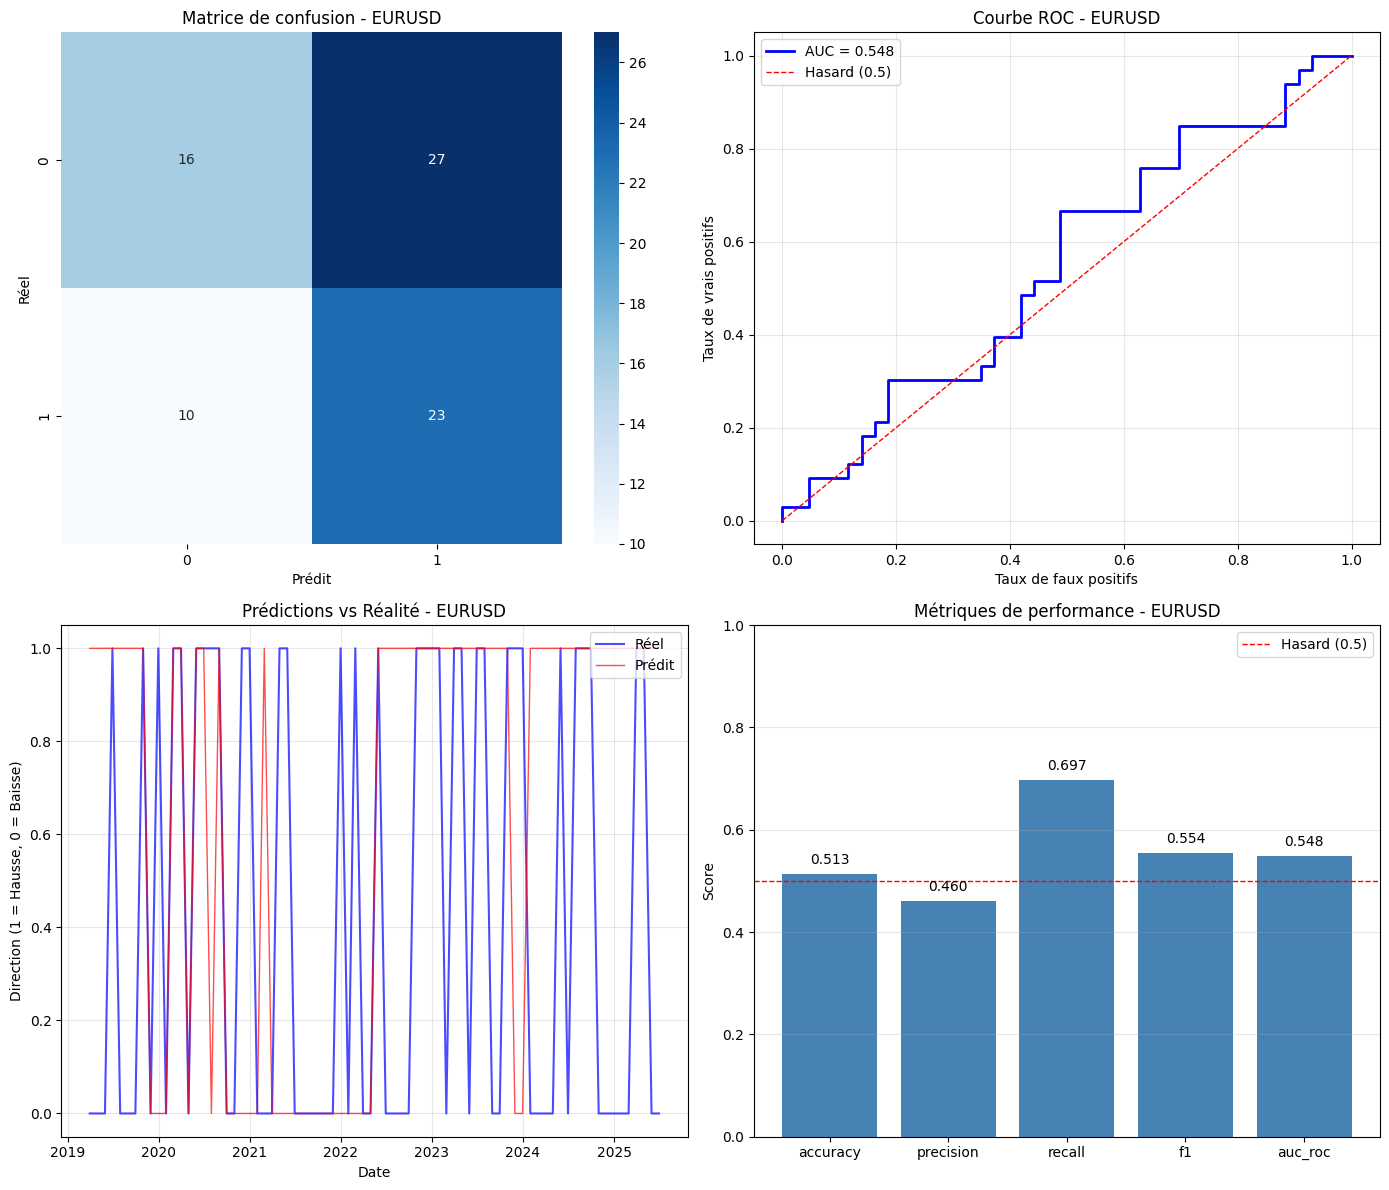


TRAITEMENT : EURJPY

EURJPY :
  Observations totales : 266
  Train : 187 (2003-05-31 à 2018-11-30)
  Test  : 79 (2018-12-31 à 2025-06-30)
  Features disponibles : 19/19

  Recherche des meilleurs hyperparamètres...
  ✅ Meilleurs paramètres : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
  Accuracy : 0.6203
  AUC-ROC  : 0.6552
  ✅ Graphique sauvegardé


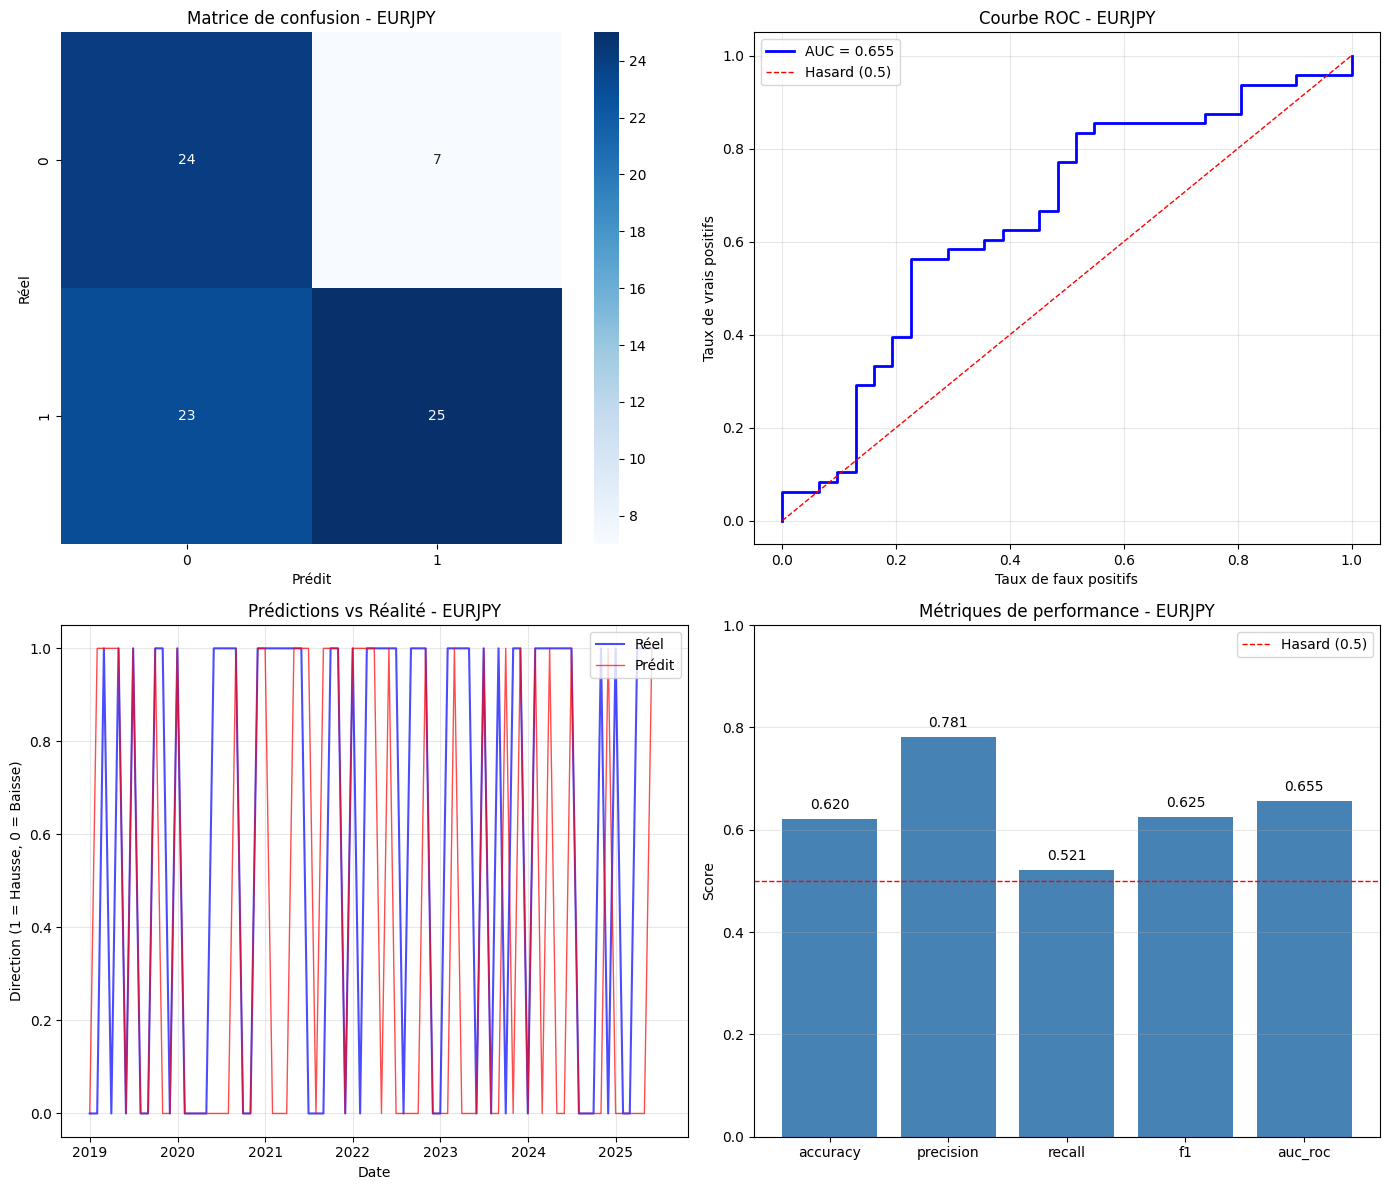


TRAITEMENT : USDCHF

USDCHF :
  Observations totales : 259
  Train : 182 (2003-12-31 à 2019-01-31)
  Test  : 77 (2019-02-28 à 2025-06-30)
  Features disponibles : 19/19

  Recherche des meilleurs hyperparamètres...
  ✅ Meilleurs paramètres : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
  Accuracy : 0.4675
  AUC-ROC  : 0.4549
  ✅ Graphique sauvegardé


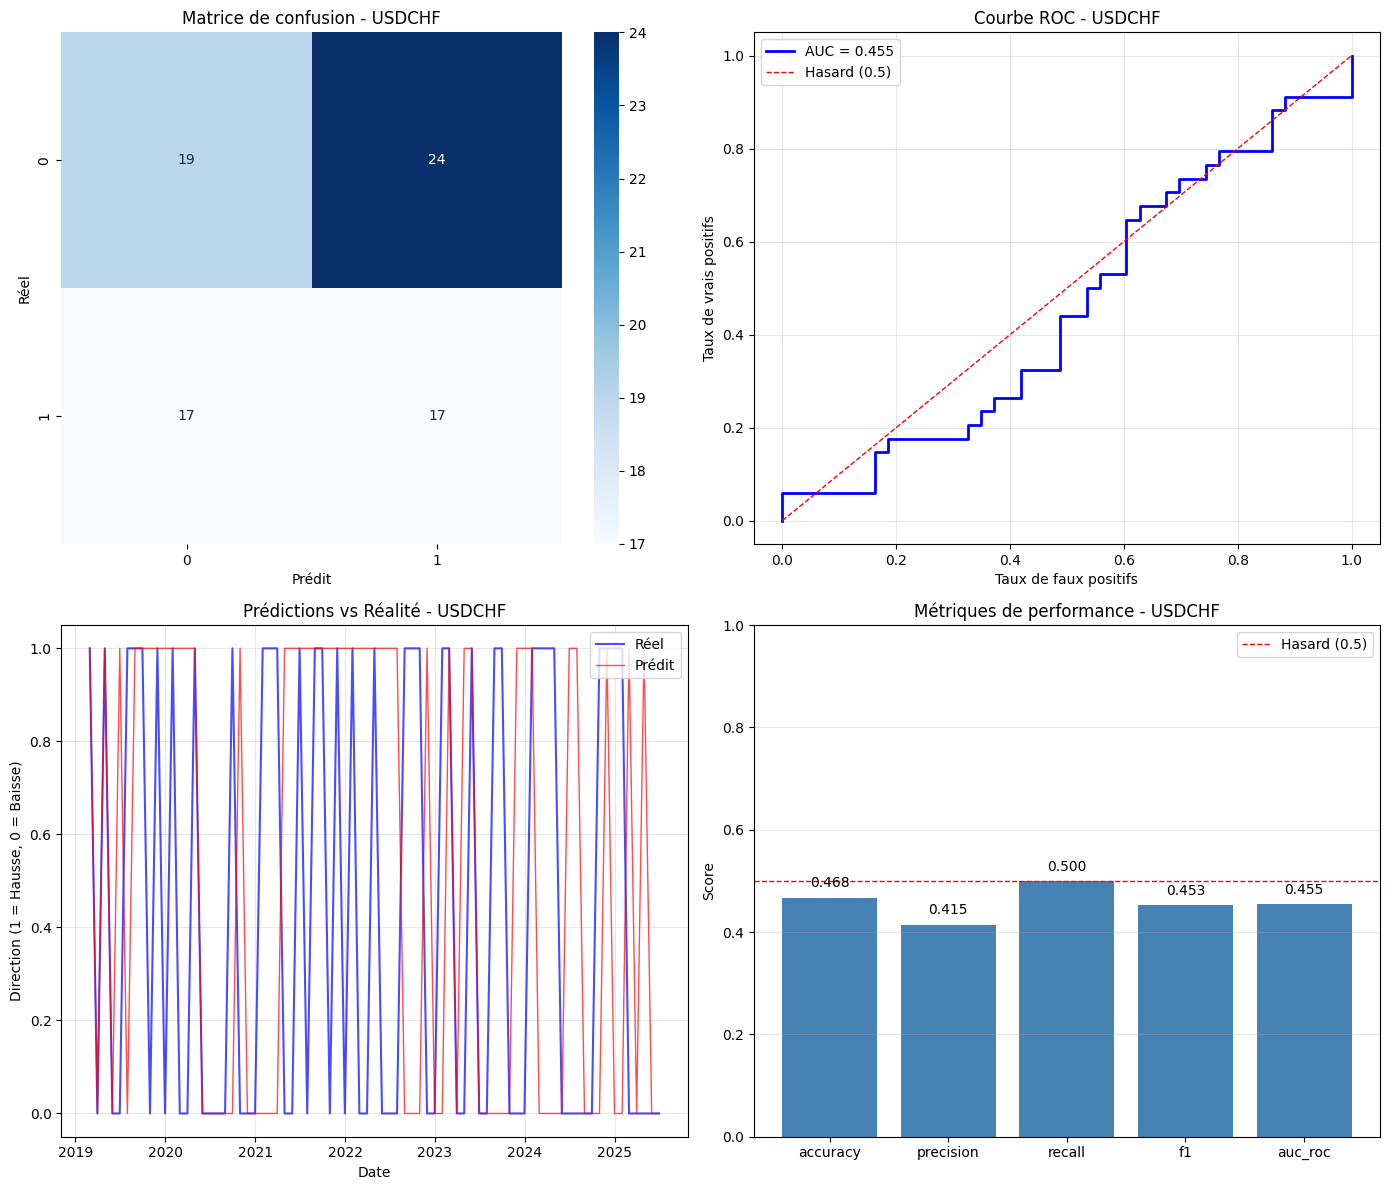


TRAITEMENT : USDCAD

USDCAD :
  Observations totales : 259
  Train : 182 (2003-12-31 à 2019-01-31)
  Test  : 77 (2019-02-28 à 2025-06-30)
  Features disponibles : 19/19

  Recherche des meilleurs hyperparamètres...
  ✅ Meilleurs paramètres : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
  Accuracy : 0.4805
  AUC-ROC  : 0.5047
  ✅ Graphique sauvegardé


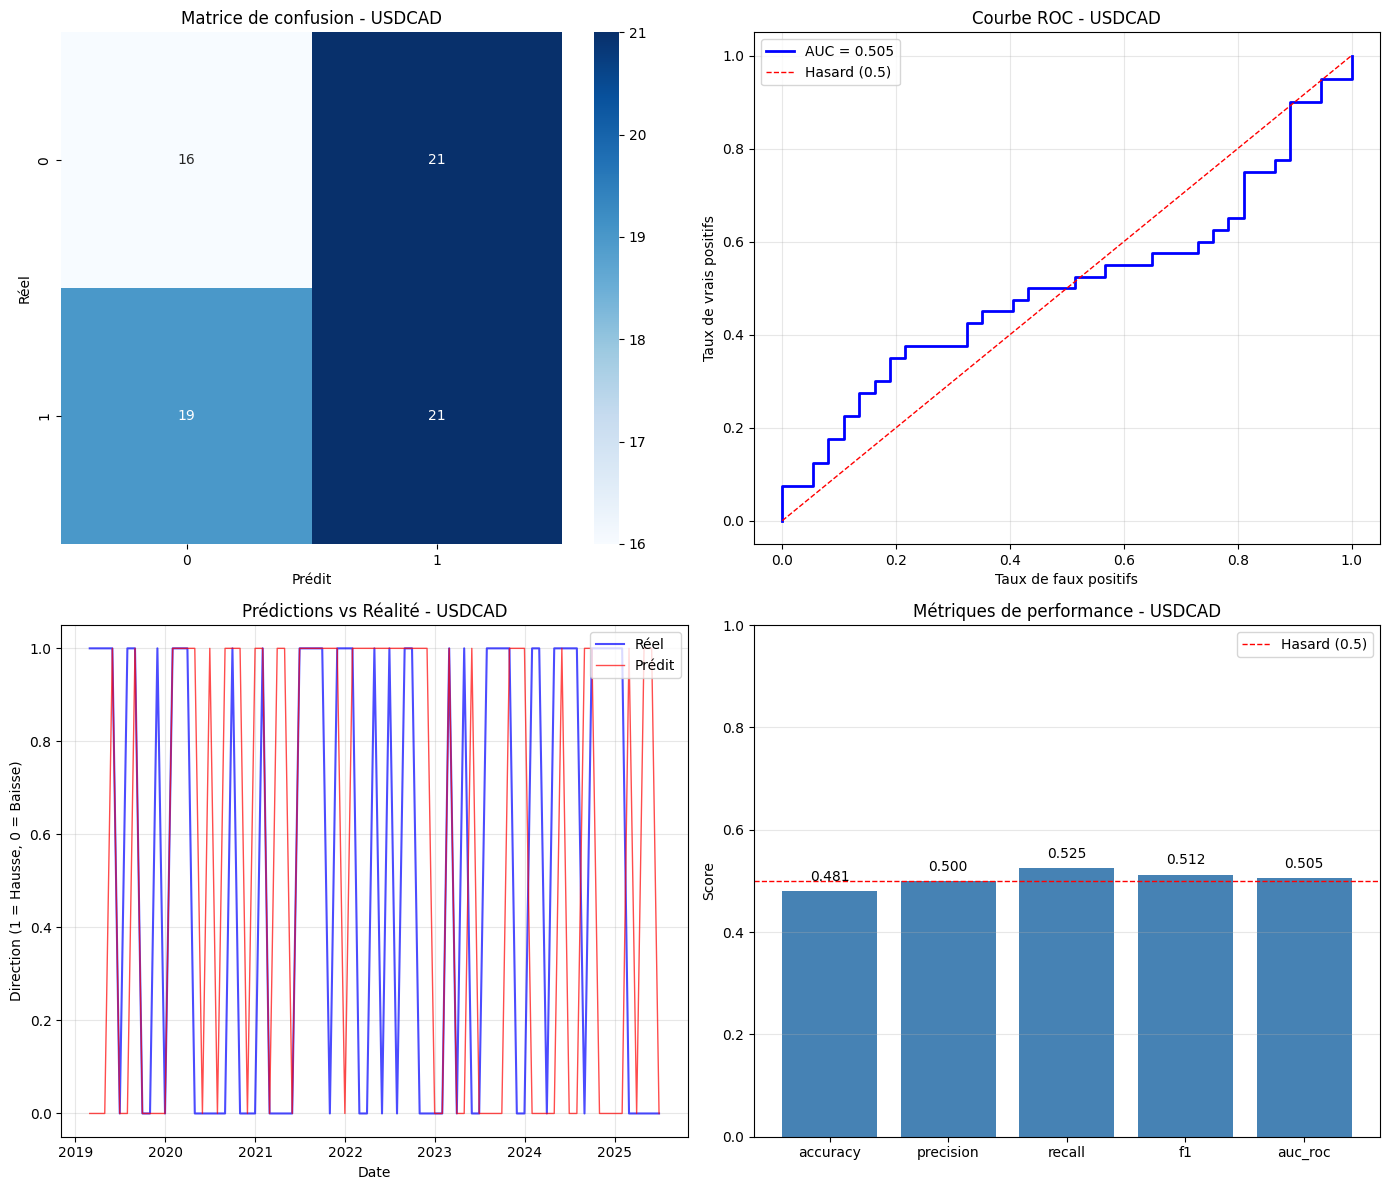


TRAITEMENT : AUDUSD

AUDUSD :
  Observations totales : 227
  Train : 159 (2006-08-31 à 2019-10-31)
  Test  : 68 (2019-11-30 à 2025-06-30)
  Features disponibles : 19/19

  Recherche des meilleurs hyperparamètres...
  ✅ Meilleurs paramètres : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
  Accuracy : 0.5441
  AUC-ROC  : 0.5619
  ✅ Graphique sauvegardé


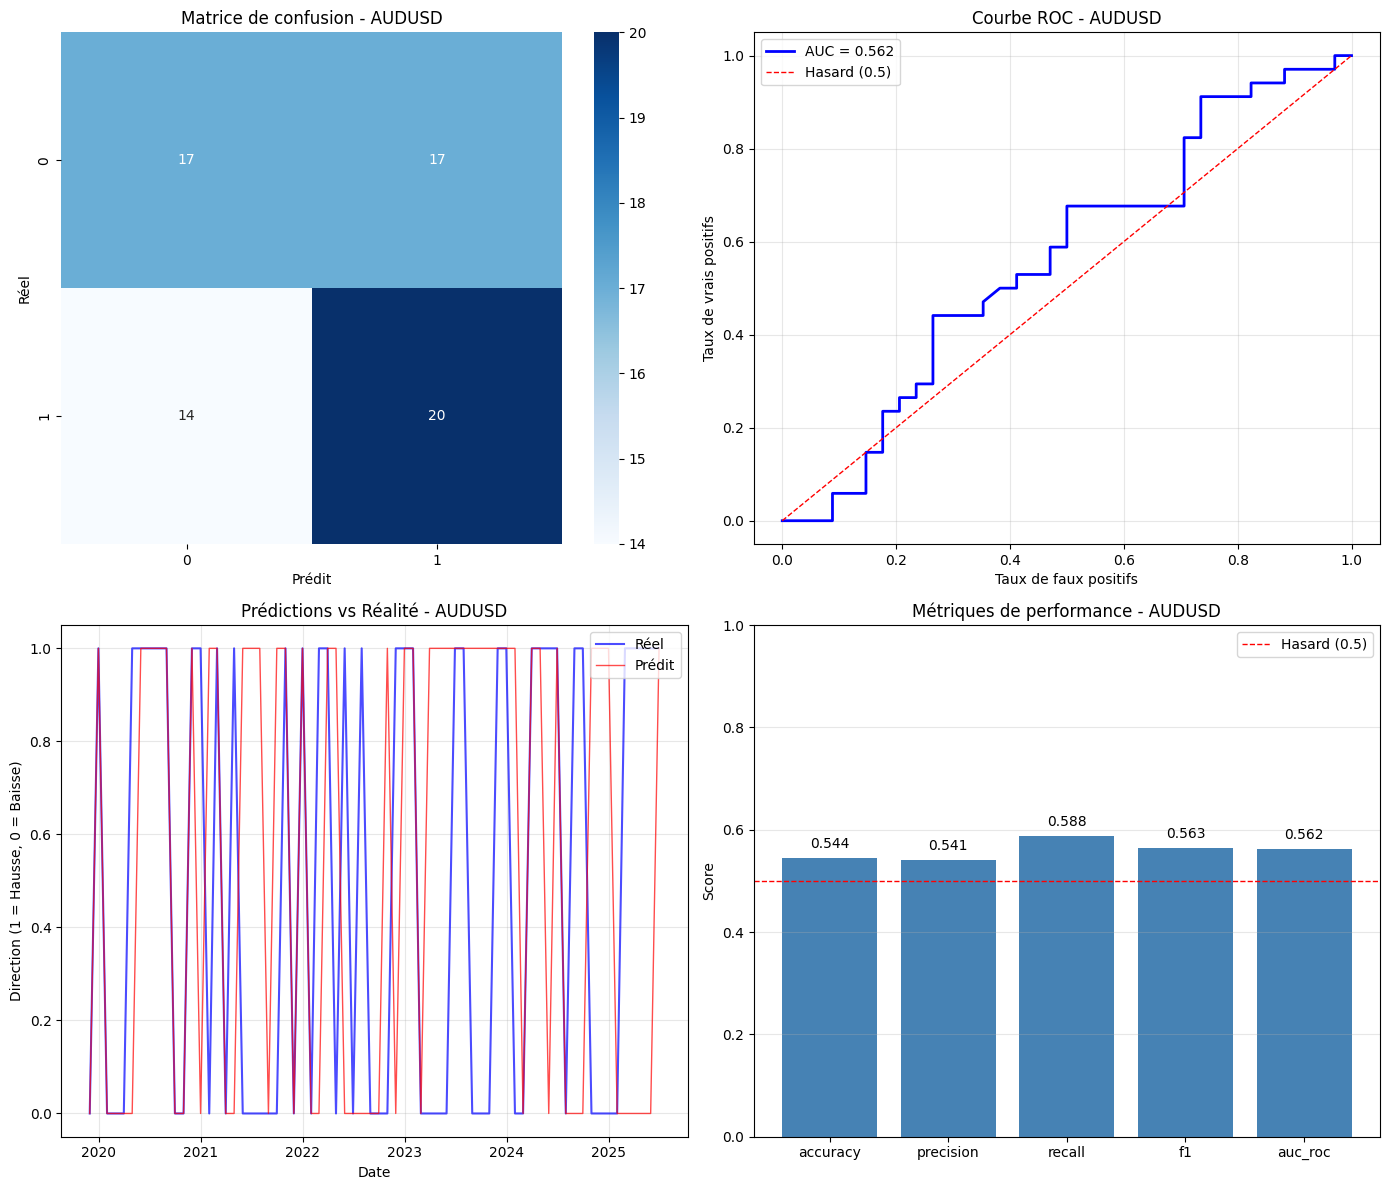


TABLEAU RÉCAPITULATIF FINAL
 Paire  Accuracy  AUC_ROC  p_value Significatif
EURUSD  0.513158 0.548273 0.454388          NON
EURJPY  0.620253 0.655242 0.021083          OUI
USDCHF  0.467532 0.454856 0.752809          NON
USDCAD  0.480519 0.504730 0.675604          NON
AUDUSD  0.544118 0.561851 0.272306          NON

✅ Résultats sauvegardés : C:\Users\alexis steevenson\Documents\forex_research_outputs\results\all_pairs_results.csv


In [25]:
# Dictionnaire pour stocker tous les résultats
all_results = []

print("\n" + "="*60)
print("ANALYSE SUR TOUTES LES PAIRES AVEC OPTIMISATION")
print("="*60)

for pair in PAIRS:
    print(f"\n{'='*50}")
    print(f"TRAITEMENT : {pair.upper()}")
    print(f"{'='*50}")
    
    # Charger les données
    df = df_raw[pair].copy()
    
    # Prétraitement
    data = preprocess_pair(df, pair, FEATURES, TARGET)
    
    # Entraînement avec optimisation
    results = train_xgboost(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        pair
    )
    
    # Test binomial
    n_correct = (results['y_pred'] == data['y_test']).sum()
    n_total = len(data['y_test'])
    binom_result = binomtest(n_correct, n_total, p=0.5, alternative='greater')
    p_value = binom_result.pvalue
    
    # Stocker les résultats
    all_results.append({
        'Paire': pair.upper(),
        'Accuracy': results['metrics']['accuracy'],
        'Precision': results['metrics']['precision'],
        'Recall': results['metrics']['recall'],
        'F1': results['metrics']['f1'],
        'AUC_ROC': results['metrics']['auc_roc'],
        'p_value': p_value,
        'Significatif': 'OUI' if p_value < 0.05 else 'NON',
        'Best_params': str(results['best_params']),
        'Train_size': len(data['X_train']),
        'Test_size': len(data['X_test'])
    })
    
    # Visualisation
    plot_results(pair, data, results, save=True)

# Tableau final
print("\n" + "="*60)
print("TABLEAU RÉCAPITULATIF FINAL")
print("="*60)

df_results = pd.DataFrame(all_results)
print(df_results[['Paire', 'Accuracy', 'AUC_ROC', 'p_value', 'Significatif']].to_string(index=False))

# Sauvegarde
df_results.to_csv(f"{OUTPUT_PATH}\\results\\all_pairs_results.csv", index=False)
print(f"\n✅ Résultats sauvegardés : {OUTPUT_PATH}\\results\\all_pairs_results.csv")

In [26]:
print("\n" + "="*60)
print("MEILLEURS HYPERPARAMÈTRES PAR PAIRE")
print("="*60)

for result in all_results:
    print(f"\n{result['Paire']} :")
    print(f"  Accuracy : {result['Accuracy']:.4f}")
    print(f"  Best params : {result['Best_params']}")


MEILLEURS HYPERPARAMÈTRES PAR PAIRE

EURUSD :
  Accuracy : 0.5132
  Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

EURJPY :
  Accuracy : 0.6203
  Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

USDCHF :
  Accuracy : 0.4675
  Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}

USDCAD :
  Accuracy : 0.4805
  Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

AUDUSD :
  Accuracy : 0.5441
  Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}


In [28]:
import pandas as pd

# Créer le tableau récapitulatif
summary_data = []
for result in all_results:
    summary_data.append({
        'Paire': result['Paire'],
        'Accuracy': f"{result['Accuracy']:.4f}",
        'AUC-ROC': f"{result['AUC_ROC']:.4f}",
        'p-value': f"{result['p_value']:.4f}",
        'Significatif à 5%': result['Significatif'],
        'n_estimators': eval(result['Best_params'])['n_estimators'],
        'max_depth': eval(result['Best_params'])['max_depth'],
        'learning_rate': eval(result['Best_params'])['learning_rate']
    })

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("TABLEAU RÉCAPITULATIF DES RÉSULTATS")
print("="*70)
print(df_summary.to_string(index=False))


TABLEAU RÉCAPITULATIF DES RÉSULTATS
 Paire Accuracy AUC-ROC p-value Significatif à 5%  n_estimators  max_depth  learning_rate
EURUSD   0.5132  0.5483  0.4544               NON           100          3           0.01
EURJPY   0.6203  0.6552  0.0211               OUI           200          7           0.10
USDCHF   0.4675  0.4549  0.7528               NON           100          7           0.10
USDCAD   0.4805  0.5047  0.6756               NON           200          7           0.05
AUDUSD   0.5441  0.5619  0.2723               NON           100          7           0.05
